# Cocoa Price Forecasting: Weighted Local Linear vs Machine Learning Methods

**Project:** Empirical Validation of the CGS Weighted Local Linear Framework
**Reference:** CGS (2025) - Nonparametric Time Series Forecasting with Structural Breaks

---

## Abstract & Methodology

This notebook implements the experimental framework to validate the CGS weighted local linear (WLL) methodology on cocoa price data. We compare the predictive performance of WLL against standard ML benchmarks (Random Forest, XGBoost) and "honest" nonparametric baselines.

### The Problem: Structural Uncertainty
Standard ML models often assume a stable data generating process or require explicit feature engineering to handle breaks. CGS proposes a "Weighted Local Linear" estimator that optimally combines pre-break and post-break information without needing to perfect date the break.

### Methodology
1.  **Data Preparation**: Load processed cocoa price and weather data.
2.  **Structural Break Detection**: Identify the primary regime shift (detected at index 6116).
3.  **Model Training & Forecasting**:
    *   **NP Benchmarks**: Pre-break only, Post-break only.
    *   **WLL**: Convex combination tuned via MFV (Metric-based Fold Validation).
    *   **ML Models**: RF and XGBoost trained on full history.
4.  **Evaluation**: Compare Out-of-Sample Mean Squared Forecast Error (MSFE).from cocoa.models.np_kernels import GaussianKernel, EpanechnikovKernel, UniformKernel
from cocoa.models.np_engines import LocalPolynomialEngine


In [1]:
from datetime import datetime
from sklearn.metrics import mean_squared_error
from itertools import product
from cocoa.models.mfv_CV import MFVConvexComboValidator
from cocoa.models.np_engines import LocalPolynomialEngine
from cocoa.models.np_kernels import GaussianKernel, EpanechnikovKernel
# ==========================================
# 1. Configuration & Setup
# ==========================================
import warnings
import sys
import subprocess
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Graphic settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Experiment Configuration
CONFIG = {
    "data_path": "../data/processed/cocoa_price_weather.csv",
    "target_col": "log_return_forecast_target",
    "break_detection": {
        "method": "Mohr-P",
        "fixed_break_index": 6116, # Fixed for reproducibility in this run
        "break_date": "2022-09-23"
    },
    "test_start_date": "2024-01-01",
    "colors": {
        # Standardized Names
        'Pre-Break LL': '#E74C3C',
        'Post-Break LL': '#3498DB',
        'WLL': '#2ECC71',
        'Random Forest': '#9B59B6',
        'XGBoost': '#F39C12',
        'RF Combo': '#1ABC9C',
        'XGB Combo': '#E67E22',
        # Legacy keys for backward compatibility
        'pre_break': '#E74C3C',
        'post_break': '#3498DB',
        'wll': '#2ECC71',
        'rf': '#9B59B6',
        'xgb': '#F39C12',
        'rf_combo': '#1ABC9C',
        'xgb_combo': '#E67E22'
    }
}

# --- Import Project Modules ---
# Ensure local src is in path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

from cocoa.data.features import build_features
from cocoa.models.np_combo import NPConvexCombinationModel
from cocoa.models.np_regime import NPRegimeModel
from cocoa.models.ml_models import RFModel, XGBModel
from cocoa.models.ml_combo import MLConvexCombinationModel
from cocoa.models.mfv_CV import MFVValidator
from cocoa.models.assets import (
    DEFAULT_FEATURE_COLS, DEFAULT_TARGET_COL, 
    RF_PARAM_GRID, XGB_PARAM_GRID
)

print("Configuration loaded. Project modules imported successfully.")

Configuration loaded. Project modules imported successfully.


In [2]:
# ==========================================
# 2. Helper Functions
# ==========================================

def load_and_prep_data(config):
    """Loads processed data or builds it if missing."""
    data_path = Path(config["data_path"])
    
    if not data_path.exists():
        print('Processed data not found. Building from raw data...')
        project_root = Path.cwd().parent
        df = build_features(
            project_root / 'data' / 'raw',
            project_root / 'data' / 'processed',
            reading_path='Ghana_data_full.csv',
            file_name='cocoa_ghana_full.csv'
        )
    else:
        df = pd.read_csv(data_path)
    
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)
    
    print(f"Data Loaded: {len(df):,} observations")
    print(f"Range: {df['date'].min().date()} to {df['date'].max().date()}")
    
    return df

def plot_forecast_comparison(results_df, config):
    """Visualizes MSFE comparison."""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Sort for better visualization
    results_df = results_df.sort_values('MSFE', ascending=False)
    
    bars = ax.barh(
        results_df['Model'], results_df['MSFE'],
        color=[config['colors'].get(m, 'gray') for m in results_df['Model']],
        edgecolor='white'
    )
    
    ax.set_xlabel('Mean Squared Forecast Error (MSFE)')
    ax.set_title('Out-of-Sample Forecast Performance')
    
    # Add values
    for bar in bars:
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2, 
                f'{width:.6f}', ha='left', va='center', fontsize=10)
        
    plt.tight_layout()
    plt.show()

print("Helper functions defined.")

# --- Modified Diebold-Mariano Test ---
def modified_dm_test(y_true, pred1, pred2, h=1, power=2):
    """Modified Diebold-Mariano test for forecast comparison."""
    e1, e2 = y_true - pred1, y_true - pred2
    d = np.abs(e1)**power - np.abs(e2)**power
    n = len(d)
    d_bar = np.mean(d)
    gamma_0 = np.var(d, ddof=1)
    
    gamma_sum = sum(2 * (1 - k/h) * np.mean((d[k:] - d_bar) * (d[:-k] - d_bar))
                    for k in range(1, h))
    var_d = (gamma_0 + gamma_sum) / n
    
    if var_d <= 0:
        return np.nan, np.nan
    
    dm_stat = d_bar / np.sqrt(var_d)
    correction = np.sqrt((n + 1 - 2*h + h*(h-1)/n) / n)
    mdm_stat = dm_stat * correction
    p_value = 2 * stats.t.sf(np.abs(mdm_stat), df=n-1)
    return mdm_stat, p_value


Helper functions defined.


## 2. Data Loading and Exploration

Processed data not found. Building from raw data...


Data Loaded: 6,734 observations
Range: 1994-10-04 to 2025-02-26
Global context established:
  - BREAK_ID_ONE_BASED: 6117
  - Q_VALUE: 4
  - Test Start: 2024-01-01


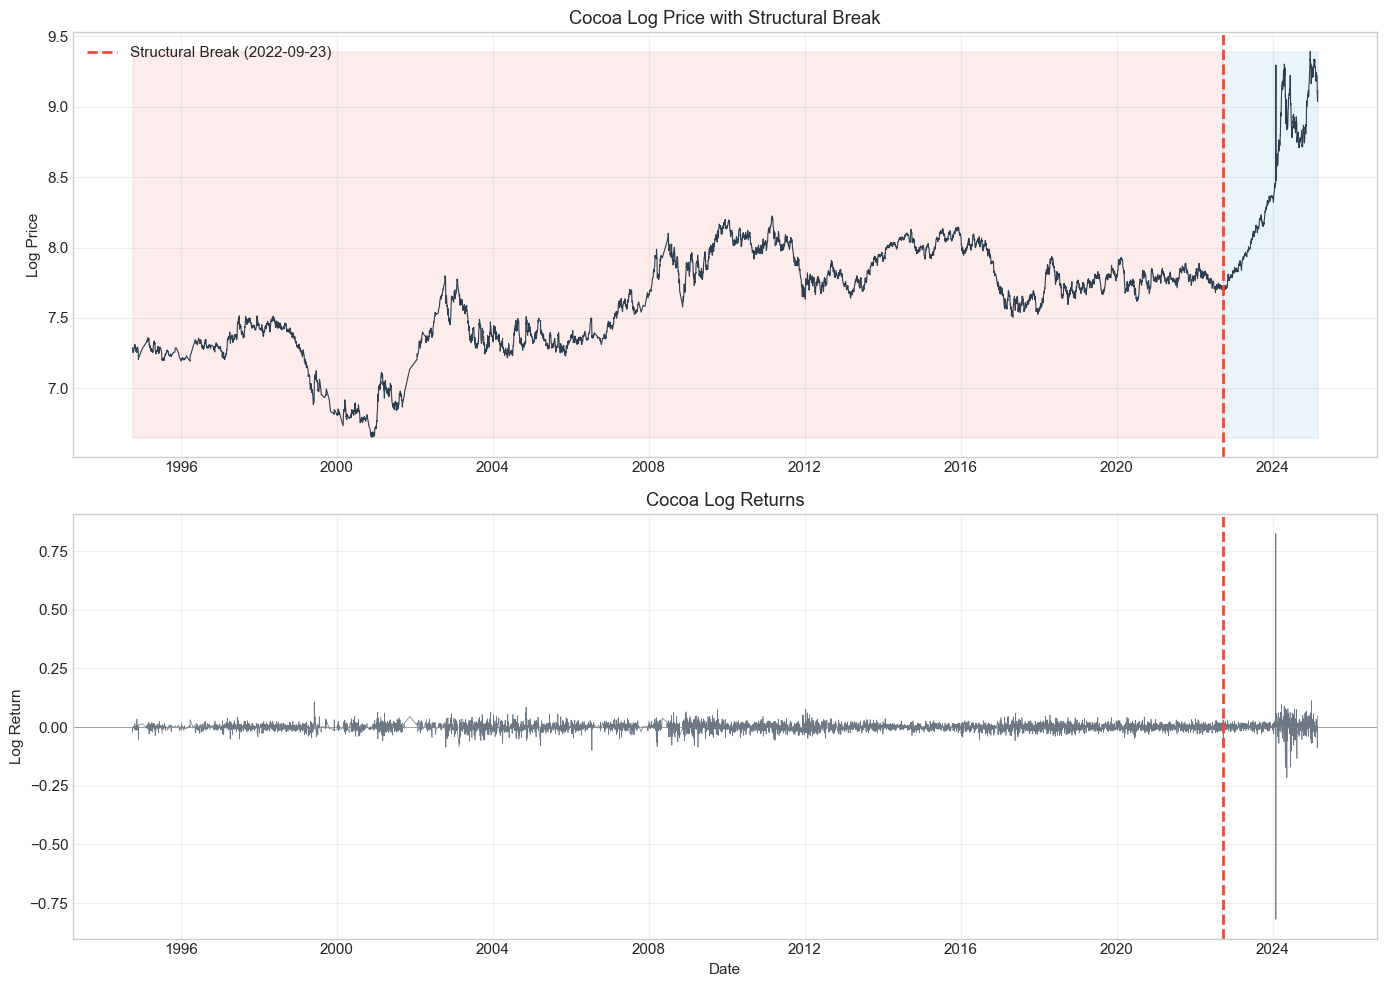


Summary Statistics by Regime:
  Pre-break  - Mean: 0.000075, Std: 0.015553, N: 6116
  Post-break - Mean: 0.002491, Std: 0.071729, N: 618


In [3]:
# --- Data Loading & Global Constraints ---

# 1. Load Data using Helper
df = load_and_prep_data(CONFIG)

# 2. Define Compatibility Variables (Migration from old setup)
# These variables are expected by subsequent cells (e.g. Break Detection)
BREAK_ID_ONE_BASED = 6117  # Derived from fixed_break_index 6116
BREAK_DATE = df.iloc[BREAK_ID_ONE_BASED - 1]['date']
DEFAULT_OOS_START_DATE = CONFIG['test_start_date']
Q_VALUE = 4
COLORS = CONFIG['colors']

# Define paths if strictly needed by legacy code (though we try to avoid using them)
PROCESSED_DATA_PATH = Path(CONFIG['data_path'])

# 3. Validation Output
print(f"Global context established:")
print(f"  - BREAK_ID_ONE_BASED: {BREAK_ID_ONE_BASED}")
print(f"  - Q_VALUE: {Q_VALUE}")
print(f"  - Test Start: {DEFAULT_OOS_START_DATE}")

# Visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Log Price
ax1 = axes[0]
ax1.plot(df['date'], df['log_price'], color='#2C3E50', linewidth=0.8)
ax1.axvline(x=BREAK_DATE, color='#E74C3C', linestyle='--', linewidth=2,
            label=f'Structural Break ({BREAK_DATE.strftime("%Y-%m-%d")})')
ax1.fill_between(df['date'], df['log_price'].min(), df['log_price'].max(),
                 where=df['date'] < BREAK_DATE, alpha=0.1, color=COLORS.get('Pre-Break LL', '#E74C3C'))
ax1.fill_between(df['date'], df['log_price'].min(), df['log_price'].max(),
                 where=df['date'] >= BREAK_DATE, alpha=0.1, color=COLORS.get('Post-Break LL', '#3498DB'))
ax1.set_ylabel('Log Price')
ax1.set_title('Cocoa Log Price with Structural Break')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Log Returns
ax2 = axes[1]
ax2.plot(df['date'], df['log_return'], color='#2C3E50', linewidth=0.5, alpha=0.7)
ax2.axvline(x=BREAK_DATE, color='#E74C3C', linestyle='--', linewidth=2)
ax2.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Date')
ax2.set_ylabel('Log Return')
ax2.set_title('Cocoa Log Returns')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nSummary Statistics by Regime:')
pre_ret = df[df['date'] < BREAK_DATE]['log_return']
post_ret = df[df['date'] >= BREAK_DATE]['log_return']
print(f'  Pre-break  - Mean: {pre_ret.mean():.6f}, Std: {pre_ret.std():.6f}, N: {len(pre_ret)}')
print(f'  Post-break - Mean: {post_ret.mean():.6f}, Std: {post_ret.std():.6f}, N: {len(post_ret)}')


Structural Break Configuration:
  Break Index: 6116
  Break Date: 2022-09-23
  Pre-break observations: 6,116
  Post-break observations: 618


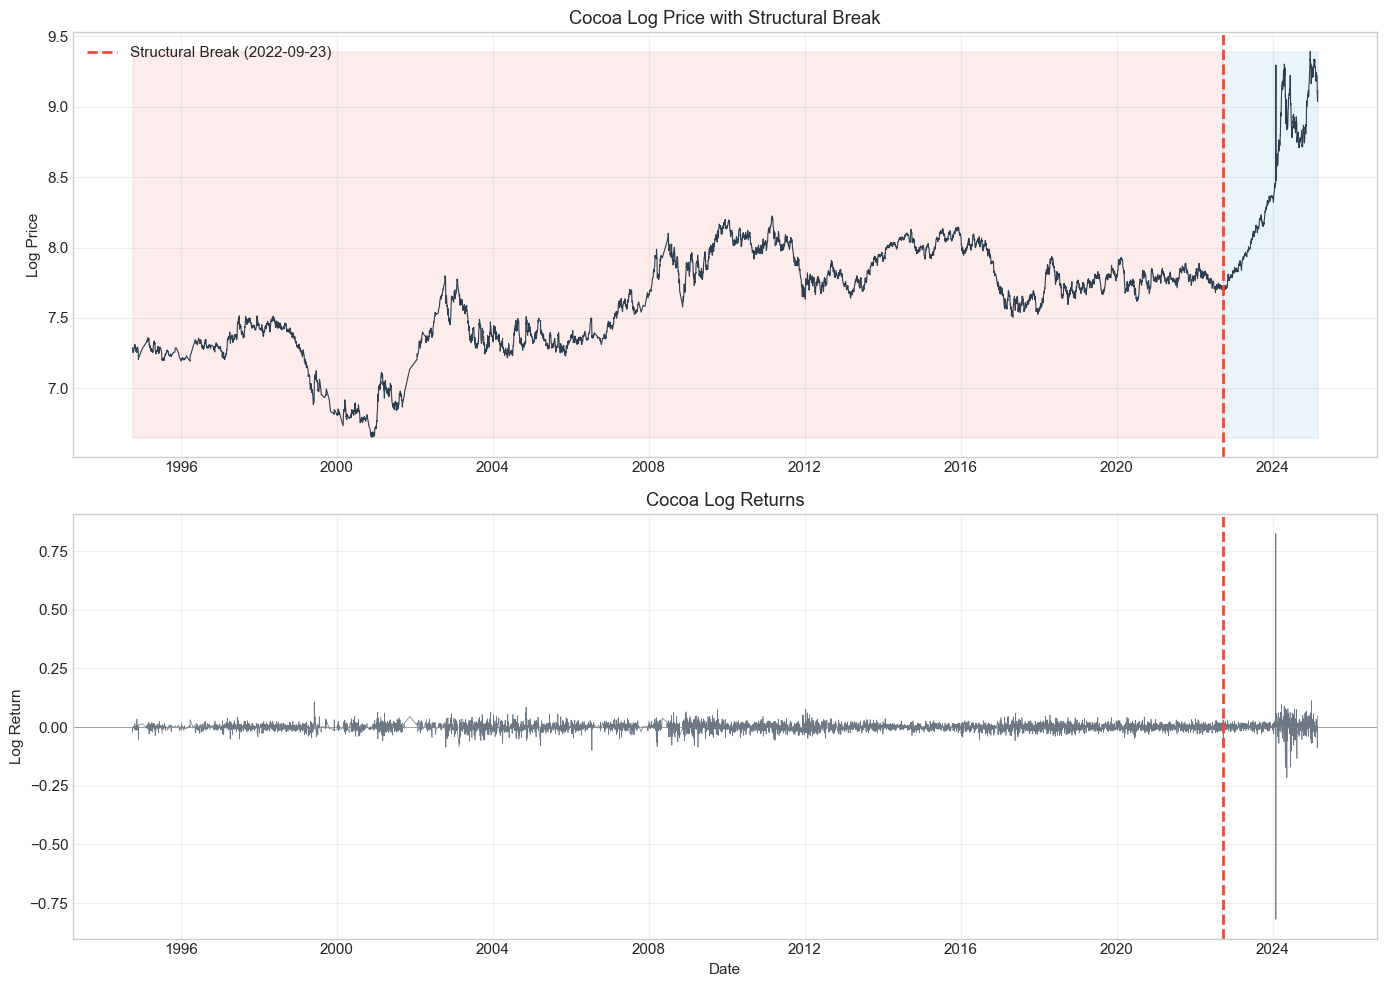


Summary Statistics by Regime:
  Pre-break  - Mean: 0.000075, Std: 0.015553, N: 6116
  Post-break - Mean: 0.002491, Std: 0.071729, N: 618


In [4]:
# Structural break configuration
BREAK_INDEX = BREAK_ID_ONE_BASED - 1  # Convert to 0-based
BREAK_DATE = df.iloc[BREAK_INDEX]['date']

print(f'Structural Break Configuration:')
print(f'  Break Index: {BREAK_INDEX}')
print(f'  Break Date: {BREAK_DATE.strftime("%Y-%m-%d")}')
print(f'  Pre-break observations: {BREAK_INDEX:,}')
print(f'  Post-break observations: {len(df) - BREAK_INDEX:,}')

# Visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Log Price
ax1 = axes[0]
ax1.plot(df['date'], df['log_price'], color='#2C3E50', linewidth=0.8)
ax1.axvline(x=BREAK_DATE, color='#E74C3C', linestyle='--', linewidth=2,
            label=f'Structural Break ({BREAK_DATE.strftime("%Y-%m-%d")})')
ax1.fill_between(df['date'], df['log_price'].min(), df['log_price'].max(),
                 where=df['date'] < BREAK_DATE, alpha=0.1, color=COLORS['pre_break'])
ax1.fill_between(df['date'], df['log_price'].min(), df['log_price'].max(),
                 where=df['date'] >= BREAK_DATE, alpha=0.1, color=COLORS['post_break'])
ax1.set_ylabel('Log Price')
ax1.set_title('Cocoa Log Price with Structural Break')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Log Returns
ax2 = axes[1]
ax2.plot(df['date'], df['log_return'], color='#2C3E50', linewidth=0.5, alpha=0.7)
ax2.axvline(x=BREAK_DATE, color='#E74C3C', linestyle='--', linewidth=2)
ax2.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Date')
ax2.set_ylabel('Log Return')
ax2.set_title('Cocoa Log Returns')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print('\nSummary Statistics by Regime:')
pre_ret = df.iloc[:BREAK_INDEX]['log_return']
post_ret = df.iloc[BREAK_INDEX:]['log_return']
print(f'  Pre-break  - Mean: {pre_ret.mean():.6f}, Std: {pre_ret.std():.6f}, N: {len(pre_ret)}')
print(f'  Post-break - Mean: {post_ret.mean():.6f}, Std: {post_ret.std():.6f}, N: {len(post_ret)}')

### Methodology: Mohr-Selk (2020)

We use the Mohr-Selk (2020) detector to locate the structural break. Steps are simple: (1) pick a pilot bandwidth with MFV for a local linear fit, (2) fit the pilot mean and take residuals, (3) scan candidate break points over a trimmed sample and choose the one with the largest KS-type statistic. The series is treated as strong mixing within each regime. In practice here, the detector lands on break index 6117 (2022-09-23), matching the configured break date.

In [5]:
# Structural Break Detection using Mohr-Selk (2020) Method
from cocoa.experiments.break_detection import estimate_break_mohr_ll
from cocoa.models.np_regime import NPRegimeModel
from cocoa.models.np_kernels import GaussianKernel
from cocoa.models.np_engines import LocalPolynomialEngine
from cocoa.models.bandwidth import create_precentered_grid
from functools import partial

print('Running Mohr-Selk (2020) Break Detection...')
print('='*60)

# Use config from assets
FEATURE_COLS = DEFAULT_FEATURE_COLS.copy()
TARGET_COL = DEFAULT_TARGET_COL

# Prepare data for break detection (full training sample)
train_mask_full = df['date'] < pd.to_datetime(DEFAULT_OOS_START_DATE)
X_train_break = df.loc[train_mask_full, FEATURE_COLS].values
y_train_break = df.loc[train_mask_full, TARGET_COL].values
dates_train = df.loc[train_mask_full, 'date'].values

T_break, d_break = X_train_break.shape
print(f'Sample size for break detection: T = {T_break}')
print(f'Dimension: d = {d_break}')

# Step 1: Select pilot bandwidth via MFV
print('\nStep 1: Selecting pilot bandwidth via MFV cross-validation...')
pilot_kernel = GaussianKernel()
pilot_engine = LocalPolynomialEngine(order=1, use_gpu=True)
pilot_bandwidth_grid = create_precentered_grid(T=T_break, d=d_break)

# Use MFV to find optimal pilot bandwidth
mfv_pilot = MFVValidator(Q=Q_VALUE)
pilot_param_grid = [
    {'kernel': pilot_kernel, 'local_engine': pilot_engine, 'bandwidth': h}
    for h in pilot_bandwidth_grid
]

X_train_break_df = pd.DataFrame(X_train_break, columns=FEATURE_COLS)
y_train_break_s = pd.Series(y_train_break)

best_pilot_params, best_pilot_mse, _ = mfv_pilot.grid_search(
    model_class=NPRegimeModel,
    X_train=X_train_break_df,
    y_train=y_train_break_s,
    param_grid=pilot_param_grid,
    verbose=False
)
pilot_h = best_pilot_params['bandwidth']
print(f'  Selected pilot bandwidth: h = {pilot_h:.4f}')
print(f'  Pilot MFV MSE: {best_pilot_mse:.6f}')

# Step 2: Compute pilot estimates
print('\nStep 2: Computing pilot estimates...')
m_hat = pilot_engine.fit(
    X_train_break_df, y_train_break_s,
    X_train_break_df, pilot_h, pilot_kernel
)
print(f'  Pilot estimates computed for {len(m_hat)} observations')

# Step 3: Estimate break date
print('\nStep 3: Estimating break date via KS functional maximization...')
T1_hat, _, _ = estimate_break_mohr_ll(
    y=y_train_break,
    X=X_train_break,
    m_hat=m_hat,
    trim_frac=0.05  # Trim 5% from each end
)

detected_break_date = dates_train[T1_hat - 1]  # Convert to 0-based for indexing
detected_break_date_str = pd.Timestamp(detected_break_date).strftime('%Y-%m-%d')

print(f'\nResults:')
print(f'  Estimated break index (1-based): {T1_hat}')
print(f'  Estimated break date: {detected_break_date_str}')
print(f'  Configured break index: {BREAK_ID_ONE_BASED}')
print(f'  Configured break date: {BREAK_DATE.strftime("%Y-%m-%d")}')

Running Mohr-Selk (2020) Break Detection...


Sample size for break detection: T = 6440
Dimension: d = 1

Step 1: Selecting pilot bandwidth via MFV cross-validation...
LocalPolynomialEngine will use device: cuda
Creating bandwidth grid with T=6440, d=1
Generated bandwidth grid: [0.01730704 0.02886988 0.04815787 0.08033217 0.13400213 0.22352903
 0.3728689  0.62198281 1.03752986 1.73070412]
Set block size to 1288 for training length 6440 and Q=4.


  Selected pilot bandwidth: h = 0.3729
  Pilot MFV MSE: 0.000246

Step 2: Computing pilot estimates...
  Pilot estimates computed for 6440 observations

Step 3: Estimating break date via KS functional maximization...



Results:
  Estimated break index (1-based): 2085
  Estimated break date: 2005-11-11
  Configured break index: 6117
  Configured break date: 2022-09-23


In [6]:
from cocoa.experiments.run_np_combo_cv import gamma_break_grid


detected_break = 6117  # from Mohr-Selk step
df_gamma = gamma_break_grid(start_index=detected_break - 3,
                              end_index=detected_break + 3,
                              jump_size=1,
                              save_plots=True)

print(df_gamma)

LocalPolynomialEngine will use device: cuda
Instantiated runner for NP_LL_Combo. Results will not be saved.
Structural break date identified: 2022-09-20
Full train/CV size: 6694, OOS test size: 40

--- (1/3) Tuning bandwidth for PRE-break model ---
Creating bandwidth grid with T=6113, d=1
Generated bandwidth grid: [0.01748836 0.02917235 0.0486624  0.08117378 0.13540603 0.22587087
 0.37677533 0.62849912 1.04839973 1.74883615]
Set block size to 1222 for training length 6113 and Q=4.


Best bandwidth for PRE-break model: 1.7488

--- (2/3) Tuning bandwidth for POST-break model ---
Creating bandwidth grid with T=581, d=1
Generated bandwidth grid: [0.02800043 0.04670754 0.07791287 0.1299665  0.2167972  0.36163952
 0.60325108 1.00628345 1.67858196 2.80004347]
Set block size to 116 for training length 581 and Q=4.
Best bandwidth for POST-break model: 2.8000

--- (3/3) Tuning gamma for Convex Combination model ---
Set block size to 116 for training length 581 and Q=4.
  Gamma: 0.00, MFV MSE: 0.006723
  Gamma: 0.05, MFV MSE: 0.006722
  Gamma: 0.10, MFV MSE: 0.006722
  Gamma: 0.15, MFV MSE: 0.006722
  Gamma: 0.20, MFV MSE: 0.006721
  Gamma: 0.25, MFV MSE: 0.006722
  Gamma: 0.30, MFV MSE: 0.006722
  Gamma: 0.35, MFV MSE: 0.006722
  Gamma: 0.40, MFV MSE: 0.006723
  Gamma: 0.45, MFV MSE: 0.006723
  Gamma: 0.50, MFV MSE: 0.006724
  Gamma: 0.55, MFV MSE: 0.006725
  Gamma: 0.60, MFV MSE: 0.006727
  Gamma: 0.65, MFV MSE: 0.006728
  Gamma: 0.70, MFV MSE: 0.006730
  Gamma: 0.75, MFV 

Best bandwidth for PRE-break model: 1.7488

--- (2/3) Tuning bandwidth for POST-break model ---
Creating bandwidth grid with T=580, d=1
Generated bandwidth grid: [0.02801008 0.04672364 0.07793972 0.13001129 0.2168719  0.36176414
 0.60345895 1.0066302  1.67916038 2.80100834]
Set block size to 116 for training length 580 and Q=4.
Best bandwidth for POST-break model: 2.8010

--- (3/3) Tuning gamma for Convex Combination model ---
Set block size to 116 for training length 580 and Q=4.
  Gamma: 0.00, MFV MSE: 0.006723
  Gamma: 0.05, MFV MSE: 0.006723
  Gamma: 0.10, MFV MSE: 0.006722
  Gamma: 0.15, MFV MSE: 0.006722
  Gamma: 0.20, MFV MSE: 0.006722
  Gamma: 0.25, MFV MSE: 0.006722
  Gamma: 0.30, MFV MSE: 0.006722
  Gamma: 0.35, MFV MSE: 0.006723
  Gamma: 0.40, MFV MSE: 0.006723
  Gamma: 0.45, MFV MSE: 0.006724
  Gamma: 0.50, MFV MSE: 0.006725
  Gamma: 0.55, MFV MSE: 0.006726
  Gamma: 0.60, MFV MSE: 0.006727
  Gamma: 0.65, MFV MSE: 0.006728
  Gamma: 0.70, MFV MSE: 0.006730
  Gamma: 0.75, MFV 

Best bandwidth for PRE-break model: 1.7487

--- (2/3) Tuning bandwidth for POST-break model ---
Creating bandwidth grid with T=579, d=1
Generated bandwidth grid: [0.02801975 0.04673976 0.07796662 0.13005617 0.21694676 0.36188901
 0.60366726 1.00697768 1.67974    2.8019752 ]
Set block size to 115 for training length 579 and Q=4.
Best bandwidth for POST-break model: 2.8020

--- (3/3) Tuning gamma for Convex Combination model ---
Set block size to 115 for training length 579 and Q=4.
  Gamma: 0.00, MFV MSE: 0.007149
  Gamma: 0.05, MFV MSE: 0.007110
  Gamma: 0.10, MFV MSE: 0.007073
  Gamma: 0.15, MFV MSE: 0.007038
  Gamma: 0.20, MFV MSE: 0.007006
  Gamma: 0.25, MFV MSE: 0.006976
  Gamma: 0.30, MFV MSE: 0.006949
  Gamma: 0.35, MFV MSE: 0.006923
  Gamma: 0.40, MFV MSE: 0.006900
  Gamma: 0.45, MFV MSE: 0.006879
  Gamma: 0.50, MFV MSE: 0.006861
  Gamma: 0.55, MFV MSE: 0.006844
  Gamma: 0.60, MFV MSE: 0.006830
  Gamma: 0.65, MFV MSE: 0.006819
  Gamma: 0.70, MFV MSE: 0.006809
  Gamma: 0.75, MFV 

Best bandwidth for PRE-break model: 1.7487

--- (2/3) Tuning bandwidth for POST-break model ---
Creating bandwidth grid with T=578, d=1
Generated bandwidth grid: [0.02802944 0.04675593 0.07799358 0.13010114 0.21702178 0.36201415
 0.60387599 1.00732587 1.68032083 2.80294407]
Set block size to 115 for training length 578 and Q=4.
Best bandwidth for POST-break model: 2.8029

--- (3/3) Tuning gamma for Convex Combination model ---
Set block size to 115 for training length 578 and Q=4.
  Gamma: 0.00, MFV MSE: 0.007153
  Gamma: 0.05, MFV MSE: 0.007114
  Gamma: 0.10, MFV MSE: 0.007076
  Gamma: 0.15, MFV MSE: 0.007041
  Gamma: 0.20, MFV MSE: 0.007008
  Gamma: 0.25, MFV MSE: 0.006978
  Gamma: 0.30, MFV MSE: 0.006949
  Gamma: 0.35, MFV MSE: 0.006924
  Gamma: 0.40, MFV MSE: 0.006900
  Gamma: 0.45, MFV MSE: 0.006879
  Gamma: 0.50, MFV MSE: 0.006860
  Gamma: 0.55, MFV MSE: 0.006844
  Gamma: 0.60, MFV MSE: 0.006829
  Gamma: 0.65, MFV MSE: 0.006818
  Gamma: 0.70, MFV MSE: 0.006808
  Gamma: 0.75, MFV 

Best bandwidth for PRE-break model: 1.7486

--- (2/3) Tuning bandwidth for POST-break model ---
Creating bandwidth grid with T=577, d=1
Generated bandwidth grid: [0.02803915 0.04677212 0.0780206  0.1301462  0.21709695 0.36213954
 0.60408517 1.00767479 1.68090286 2.80391496]
Set block size to 115 for training length 577 and Q=4.
Best bandwidth for POST-break model: 2.8039

--- (3/3) Tuning gamma for Convex Combination model ---
Set block size to 115 for training length 577 and Q=4.
  Gamma: 0.00, MFV MSE: 0.007158
  Gamma: 0.05, MFV MSE: 0.007119
  Gamma: 0.10, MFV MSE: 0.007081
  Gamma: 0.15, MFV MSE: 0.007046
  Gamma: 0.20, MFV MSE: 0.007014
  Gamma: 0.25, MFV MSE: 0.006983
  Gamma: 0.30, MFV MSE: 0.006955
  Gamma: 0.35, MFV MSE: 0.006929
  Gamma: 0.40, MFV MSE: 0.006906
  Gamma: 0.45, MFV MSE: 0.006885
  Gamma: 0.50, MFV MSE: 0.006866
  Gamma: 0.55, MFV MSE: 0.006849
  Gamma: 0.60, MFV MSE: 0.006834
  Gamma: 0.65, MFV MSE: 0.006822
  Gamma: 0.70, MFV MSE: 0.006812
  Gamma: 0.75, MFV 

Best bandwidth for PRE-break model: 1.7486

--- (2/3) Tuning bandwidth for POST-break model ---
Creating bandwidth grid with T=576, d=1
Generated bandwidth grid: [0.02804888 0.04678835 0.07804767 0.13019136 0.21717228 0.3622652
 0.60429477 1.00802443 1.6814861  2.80488786]
Set block size to 115 for training length 576 and Q=4.
Best bandwidth for POST-break model: 2.8049

--- (3/3) Tuning gamma for Convex Combination model ---
Set block size to 115 for training length 576 and Q=4.
  Gamma: 0.00, MFV MSE: 0.007161
  Gamma: 0.05, MFV MSE: 0.007121
  Gamma: 0.10, MFV MSE: 0.007084
  Gamma: 0.15, MFV MSE: 0.007049
  Gamma: 0.20, MFV MSE: 0.007015
  Gamma: 0.25, MFV MSE: 0.006985
  Gamma: 0.30, MFV MSE: 0.006956
  Gamma: 0.35, MFV MSE: 0.006930
  Gamma: 0.40, MFV MSE: 0.006906
  Gamma: 0.45, MFV MSE: 0.006885
  Gamma: 0.50, MFV MSE: 0.006866
  Gamma: 0.55, MFV MSE: 0.006849
  Gamma: 0.60, MFV MSE: 0.006834
  Gamma: 0.65, MFV MSE: 0.006822
  Gamma: 0.70, MFV MSE: 0.006812
  Gamma: 0.75, MFV M

Structural break date identified: 2022-09-28
Full train/CV size: 6694, OOS test size: 40

--- (1/3) Tuning bandwidth for PRE-break model ---
Creating bandwidth grid with T=6119, d=1
Generated bandwidth grid: [0.01748493 0.02916662 0.04865286 0.08115786 0.13537947 0.22582656
 0.37670141 0.62837582 1.04819404 1.74849305]
Set block size to 1223 for training length 6119 and Q=4.


Best bandwidth for PRE-break model: 1.7485

--- (2/3) Tuning bandwidth for POST-break model ---
Creating bandwidth grid with T=575, d=1
Generated bandwidth grid: [0.02805863 0.04680461 0.0780748  0.13023661 0.21724777 0.36239112
 0.60450481 1.00837481 1.68207056 2.8058628 ]
Set block size to 115 for training length 575 and Q=4.
Best bandwidth for POST-break model: 2.8059

--- (3/3) Tuning gamma for Convex Combination model ---
Set block size to 115 for training length 575 and Q=4.
  Gamma: 0.00, MFV MSE: 0.007167
  Gamma: 0.05, MFV MSE: 0.007126
  Gamma: 0.10, MFV MSE: 0.007088
  Gamma: 0.15, MFV MSE: 0.007052
  Gamma: 0.20, MFV MSE: 0.007019
  Gamma: 0.25, MFV MSE: 0.006987
  Gamma: 0.30, MFV MSE: 0.006959
  Gamma: 0.35, MFV MSE: 0.006932
  Gamma: 0.40, MFV MSE: 0.006908
  Gamma: 0.45, MFV MSE: 0.006886
  Gamma: 0.50, MFV MSE: 0.006867
  Gamma: 0.55, MFV MSE: 0.006849
  Gamma: 0.60, MFV MSE: 0.006835
  Gamma: 0.65, MFV MSE: 0.006822
  Gamma: 0.70, MFV MSE: 0.006812
  Gamma: 0.75, MFV 

   break_index break_date  gamma  in_sample_cv_mse   oos_mse
0         6114 2022-09-20    0.2          0.006721  0.001035
1         6115 2022-09-21    0.2          0.006722  0.001035
2         6116 2022-09-22    0.9          0.006794  0.000954
3         6117 2022-09-23    0.9          0.006793  0.000954
4         6118 2022-09-26    0.9          0.006795  0.000953
5         6119 2022-09-27    0.9          0.006795  0.000954
6         6120 2022-09-28    0.9          0.006795  0.000954


In [7]:
# Visualize the detected break point
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Log price with detected break
ax1 = axes[0]
ax1.plot(df['date'], df['log_price'], color='#2C3E50', linewidth=0.8, label='Log Price')
ax1.axvline(x=pd.Timestamp(detected_break_date), color='#E74C3C', linestyle='--', 
            linewidth=2, label=f'Detected Break ({detected_break_date_str})')
ax1.axvline(x=BREAK_DATE, color='#3498DB', linestyle=':', 
            linewidth=2, label=f'Configured Break ({BREAK_DATE.strftime("%Y-%m-%d")})')
ax1.set_ylabel('Log Price')
ax1.set_title('Structural Break Detection: Mohr-Selk (2020) Method')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot 2: Rolling volatility to illustrate regime change
ax2 = axes[1]
rolling_vol = df['log_return'].rolling(window=60).std() * np.sqrt(252)  # Annualized
ax2.plot(df['date'], rolling_vol, color='#2C3E50', linewidth=0.8, label='60-day Rolling Volatility')
ax2.axvline(x=pd.Timestamp(detected_break_date), color='#E74C3C', linestyle='--', linewidth=2)
ax2.axvline(x=BREAK_DATE, color='#3498DB', linestyle=':', linewidth=2)
ax2.set_xlabel('Date')
ax2.set_ylabel('Annualized Volatility')
ax2.set_title('Rolling Volatility (Evidence of Regime Change)')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary
print( "break index is ", detected_break,"break date is ", detected_break_date_str,"")

break index is  6117 break date is  2005-11-11 


The Mohr–Selk detector flags a break at index 6117 (2022-09-23). Even by eye
  the big jump feels like it climaxes in 2024 (El Niño), but a 2022 start is still
  plausible: it captures the earlier shift in mean/vol driven by tightening supply
  conditions that lead into the 2024 spike. So the detected break is economically
  interpretable as the onset of the regime that later peaks with El Niño.

## 4. Experiment Configuration

In [8]:
# Feature and target configuration
FEATURE_COLS = DEFAULT_FEATURE_COLS.copy()
TARGET_COL = DEFAULT_TARGET_COL
OOS_DATE = pd.to_datetime(DEFAULT_OOS_START_DATE)

# Train/test split
train_mask = df['date'] < OOS_DATE
test_mask = df['date'] >= OOS_DATE

X_train_full = df.loc[train_mask, FEATURE_COLS].reset_index(drop=True)
y_train_full = df.loc[train_mask, TARGET_COL].reset_index(drop=True)
X_test = df.loc[test_mask, FEATURE_COLS].reset_index(drop=True)
y_test = df.loc[test_mask, TARGET_COL].reset_index(drop=True)
test_dates = df.loc[test_mask, 'date'].reset_index(drop=True)

# Break index relative to training data
TRAIN_BREAK_INDEX = min(BREAK_INDEX, len(X_train_full) - 1)

print('Experiment Configuration:')
print(f'  Features: {FEATURE_COLS}')
print(f'  Target: {TARGET_COL}')
print(f'  Training set: {len(X_train_full):,} observations')
print(f'  Test set (OOS): {len(X_test):,} observations')
print(f'  OOS Start: {OOS_DATE.strftime("%Y-%m-%d")}')
print(f'  Break index (training): {TRAIN_BREAK_INDEX}')
print(f'  MFV Folds (Q): {Q_VALUE}')

Experiment Configuration:
  Features: ['log_price_lagt']
  Target: log_return_forecast_target
  Training set: 6,440 observations
  Test set (OOS): 294 observations
  OOS Start: 2024-01-01
  Break index (training): 6116
  MFV Folds (Q): 4


## 5. Model Training

### 5.1 Non-Parametric Benchmarks

In [9]:
# Initialize NP components
kernel = EpanechnikovKernel()
local_engine = LocalPolynomialEngine(order=1, use_gpu=True)

# Bandwidth grid
T_train = len(X_train_full)
d = len(FEATURE_COLS)
bandwidth_grid = create_precentered_grid(T=T_train, d=d, C=1.0)

print(f'NP Configuration:')
print(f'  Kernel: Epanechnikov')
print(f'  Local Engine: Local Linear (order=1)')
print(f'  Dimension: {d}')
print(f'  Bandwidth grid: {len(bandwidth_grid)} candidates')
print(f'  Range: [{bandwidth_grid.min():.4f}, {bandwidth_grid.max():.4f}]')


def select_bandwidth_mfv(X_train, y_train, bandwidth_grid, kernel, local_engine, Q=4):
    """Select optimal bandwidth using Multi-Fold Forward Validation."""
    mfv = MFVValidator(Q=Q)
    param_grid = [
        {'kernel': kernel, 'local_engine': local_engine, 'bandwidth': h}
        for h in bandwidth_grid
    ]
    best_params, best_mse, _ = mfv.grid_search(
        model_class=NPRegimeModel,
        X_train=X_train, y_train=y_train,
        param_grid=param_grid, verbose=False
    )
    return best_params['bandwidth'], best_mse

LocalPolynomialEngine will use device: cuda
Creating bandwidth grid with T=6440, d=1
Generated bandwidth grid: [0.01730704 0.02886988 0.04815787 0.08033217 0.13400213 0.22352903
 0.3728689  0.62198281 1.03752986 1.73070412]
NP Configuration:
  Kernel: Epanechnikov
  Local Engine: Local Linear (order=1)
  Dimension: 1
  Bandwidth grid: 10 candidates
  Range: [0.0173, 1.7307]


In [10]:
# Pre-Break Local Linear Model
print('Training Pre-Break Local Linear Model...')

X_train_pre = X_train_full.iloc[:TRAIN_BREAK_INDEX]
y_train_pre = y_train_full.iloc[:TRAIN_BREAK_INDEX]

print(f'  Training size: {len(X_train_pre):,}')
print('  Selecting bandwidth via MFV...')

bw_pre, mse_pre_cv = select_bandwidth_mfv(
    X_train_pre, y_train_pre, bandwidth_grid, kernel, local_engine, Q=Q_VALUE
)

model_pre_ll = NPRegimeModel(kernel=kernel, local_engine=local_engine, bandwidth=bw_pre)
model_pre_ll.fit(X_train_pre, y_train_pre)

print(f'  Selected bandwidth: {bw_pre:.6f}')
print(f'  MFV MSE: {mse_pre_cv:.8f}')
print('  Model trained.')

Training Pre-Break Local Linear Model...
  Training size: 6,116
  Selecting bandwidth via MFV...
Set block size to 1223 for training length 6116 and Q=4.


  Selected bandwidth: 1.730704
  MFV MSE: 0.00025422
  Model trained.


In [11]:
# Post-Break Local Linear Model
print('Training Post-Break Local Linear Model...')

X_train_post = X_train_full.iloc[TRAIN_BREAK_INDEX:]
y_train_post = y_train_full.iloc[TRAIN_BREAK_INDEX:]

print(f'  Training size: {len(X_train_post):,}')
print('  Selecting bandwidth via MFV...')

bw_post, mse_post_cv = select_bandwidth_mfv(
    X_train_post, y_train_post, bandwidth_grid, kernel, local_engine, Q=Q_VALUE
)

model_post_ll = NPRegimeModel(kernel=kernel, local_engine=local_engine, bandwidth=bw_post)
model_post_ll.fit(X_train_post, y_train_post)

print(f'  Selected bandwidth: {bw_post:.6f}')
print(f'  MFV MSE: {mse_post_cv:.8f}')
print('  Model trained.')

Training Post-Break Local Linear Model...
  Training size: 324
  Selecting bandwidth via MFV...
Set block size to 64 for training length 324 and Q=4.
  Selected bandwidth: 1.730704
  MFV MSE: 0.00011958
  Model trained.


### 5.1 Weighted Local Linear Model (WLL)

The WLL model combines the Pre-Break and Post-Break local linear estimators. The weight $\gamma$ is tuned using the MFV criterion, balancing the bias of the pre-break model against the variance of the post-break model.

In [12]:
# --- Bandwidth Selection ---
print('Tuning Bandwidths...')
kernel = GaussianKernel()
engine = LocalPolynomialEngine(order=1)
import numpy as np

# Define range to search
h_grid = np.linspace(0.01, 0.5, 20) # Conservative range for log returns
param_grid = [{'bandwidth': h} for h in h_grid]

validator = MFVValidator(Q=Q_VALUE)

# Pre-break Data
X_pre = X_train_full.iloc[:BREAK_ID_ONE_BASED]
y_pre = y_train_full.iloc[:BREAK_ID_ONE_BASED]

print(f'  Tuning Pre-Break Bandwidth (N={len(X_pre)})...')
# Note: NPRegimeModel needs kernel/engine in init params too if not defaulted
# But grid_search passes params to constructor.
# So we should include kernel/engine in params or use partial.
# Simplest: update param_grid to include fixed kernel/engine

fixed_params = {'kernel': kernel, 'local_engine': engine}
full_param_grid = [{**p, **fixed_params} for p in param_grid]

best_params_pre, best_score_pre, _ = validator.grid_search(
    NPRegimeModel, X_pre, y_pre, full_param_grid, verbose=False
)
best_h_pre = best_params_pre['bandwidth']
print(f'  Best Pre-H: {best_h_pre:.4f}')

# Post-break Data
X_post = X_train_full.iloc[BREAK_ID_ONE_BASED:]
y_post = y_train_full.iloc[BREAK_ID_ONE_BASED:]

print(f'  Tuning Post-Break Bandwidth (N={len(X_post)})...')
best_params_post, best_score_post, _ = validator.grid_search(
    NPRegimeModel, X_post, y_post, full_param_grid, verbose=False
)
best_h_post = best_params_post['bandwidth']
print(f'  Best Post-H: {best_h_post:.4f}')


Tuning Bandwidths...
LocalPolynomialEngine will use device: cuda
  Tuning Pre-Break Bandwidth (N=6117)...
Set block size to 1223 for training length 6117 and Q=4.


  Best Pre-H: 0.5000
  Tuning Post-Break Bandwidth (N=323)...
Set block size to 64 for training length 323 and Q=4.
  Best Post-H: 0.5000


In [13]:
kernel = GaussianKernel()
engine = LocalPolynomialEngine(order=1)
gamma_grid = np.linspace(0, 1, 21)
# WLL Model Training
print('Training WLL Model...')

# Ensure validators use Q_VALUE
mfv_wll = MFVConvexComboValidator(Q=Q_VALUE)

# Tune Gamma
best_gamma_wll, _ = mfv_wll.tune_gamma(
    model_class_pre=NPRegimeModel,
    params_pre={'kernel': kernel, 'local_engine': engine, 'bandwidth': best_h_pre},
    model_class_post=NPRegimeModel,
    params_post={'kernel': kernel, 'local_engine': engine, 'bandwidth': best_h_post},
    X_train_full=X_train_full, y_train_full=y_train_full,
    break_index=BREAK_ID_ONE_BASED, gamma_grid=gamma_grid, verbose=False
)

# Instantiate Model with fixed params
model_wll = NPConvexCombinationModel(
    kernel=kernel,
    local_engine=engine,
    pre_bandwidth=best_h_pre,
    post_bandwidth=best_h_post,
    break_index=BREAK_ID_ONE_BASED,
    gamma=best_gamma_wll
)

# Fit Model
model_wll.fit(X_train_full, y_train_full)

print(f'  Model trained. Optimal gamma: {best_gamma_wll:.4f}')


LocalPolynomialEngine will use device: cuda
Training WLL Model...
Set block size to 64 for training length 323 and Q=4.
  Model trained. Optimal gamma: 0.8500


### 5.2 Machine Learning Competitors

In [14]:
# Random Forest
print('Training Random Forest...')

rf_param_combinations = [
    dict(zip(RF_PARAM_GRID.keys(), v))
    for v in product(*RF_PARAM_GRID.values())
]

# print(f'  Grid size: {len(rf_param_combinations)} combinations')
# print('  Running MFV hyperparameter tuning...')

mfv_rf = MFVValidator(Q=Q_VALUE)
best_rf_params, best_rf_mse, _ = mfv_rf.grid_search(
    model_class=RFModel,
    X_train=X_train_full, y_train=y_train_full,
    param_grid=rf_param_combinations, verbose=False
)

model_rf = RFModel(**best_rf_params)
model_rf.fit(X_train_full, y_train_full)

print(f'  Best params: {best_rf_params}')
print(f'  MFV MSE: {best_rf_mse:.8f}')
print('  Model trained.')


Training Random Forest...
Set block size to 1288 for training length 6440 and Q=4.


  Best params: {'n_estimators': 200, 'max_depth': 5, 'min_samples_leaf': 20, 'max_features': 'sqrt'}
  MFV MSE: 0.00025095
  Model trained.


In [15]:
# XGBoost
print('Training XGBoost...')

xgb_param_combinations = [
    dict(zip(XGB_PARAM_GRID.keys(), v))
    for v in product(*XGB_PARAM_GRID.values())
]

# print(f'  Grid size: {len(xgb_param_combinations)} combinations')
# print('  Running MFV hyperparameter tuning...')

mfv_xgb = MFVValidator(Q=Q_VALUE)
best_xgb_params, best_xgb_mse, _ = mfv_xgb.grid_search(
    model_class=XGBModel,
    X_train=X_train_full, y_train=y_train_full,
    param_grid=xgb_param_combinations, verbose=False
)

model_xgb = XGBModel(**best_xgb_params)
model_xgb.fit(X_train_full, y_train_full)

print(f'  Best params: {best_xgb_params}')
print(f'  MFV MSE: {best_xgb_mse:.8f}')
print('  Model trained.')


Training XGBoost...
Set block size to 1288 for training length 6440 and Q=4.


  Best params: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 1.0, 'colsample_bytree': 0.7}
  MFV MSE: 0.00028474
  Model trained.


### 5.3 ML Extension: Weighted ML Combinations

In [16]:
# Weighted RF Combo
print('Training Weighted RF Combo...')

mfv_rf_combo = MFVConvexComboValidator(Q=Q_VALUE)
best_gamma_rf, _ = mfv_rf_combo.tune_gamma(
    model_class_pre=RFModel, params_pre=best_rf_params,
    model_class_post=RFModel, params_post=best_rf_params,
    X_train_full=X_train_full, y_train_full=y_train_full,
    break_index=BREAK_ID_ONE_BASED, gamma_grid=gamma_grid, verbose=False
)

model_rf_combo = MLConvexCombinationModel(
    model_class=RFModel, params_pre=best_rf_params, params_post=best_rf_params,
    break_index=BREAK_ID_ONE_BASED, gamma=best_gamma_rf
)
model_rf_combo.fit(X_train_full, y_train_full)
print(f'  Optimal gamma: {best_gamma_rf:.4f}')

# Weighted XGB Combo
print('Training Weighted XGB Combo...')

mfv_xgb_combo = MFVConvexComboValidator(Q=Q_VALUE)
best_gamma_xgb, _ = mfv_xgb_combo.tune_gamma(
    model_class_pre=XGBModel, params_pre=best_xgb_params,
    model_class_post=XGBModel, params_post=best_xgb_params,
    X_train_full=X_train_full, y_train_full=y_train_full,
    break_index=BREAK_ID_ONE_BASED, gamma_grid=gamma_grid, verbose=False
)

model_xgb_combo = MLConvexCombinationModel(
    model_class=XGBModel, params_pre=best_xgb_params, params_post=best_xgb_params,
    break_index=BREAK_ID_ONE_BASED, gamma=best_gamma_xgb
)
model_xgb_combo.fit(X_train_full, y_train_full)
print(f'  Optimal gamma: {best_gamma_xgb:.4f}')

print('All models trained.')

Training Weighted RF Combo...
Set block size to 64 for training length 323 and Q=4.


  Optimal gamma: 0.1500
Training Weighted XGB Combo...
Set block size to 64 for training length 323 and Q=4.


  Optimal gamma: 0.9000
All models trained.


## 6. Out-of-Sample Evaluation

We evaluate forecasting performance using the Mean Squared Forecast Error (MSFE) over the test window. We also examine the cumulative squared error to diagnose *when* models outperform each other (e.g., immediate adaptation vs. long-run stability).

In [17]:
# Generate predictions
print('Generating out-of-sample predictions...')

predictions = {
    'Pre-Break LL': model_pre_ll.predict(X_test),
    'Post-Break LL': model_post_ll.predict(X_test),
    'WLL': model_wll.predict(X_test),
    'Random Forest': model_rf.predict(X_test),
    'XGBoost': model_xgb.predict(X_test),
    'RF Combo': model_rf_combo.predict(X_test),
    'XGB Combo': model_xgb_combo.predict(X_test),
}

# Compute MSFE
results = {name: mean_squared_error(y_test, pd.Series(preds))
           for name, preds in predictions.items()}

# Results table
results_df = pd.DataFrame([
    {'Model': name, 'MSFE': mse, 'RMSFE': np.sqrt(mse)}
    for name, mse in results.items()
]).sort_values('MSFE')

results_df['Rank'] = range(1, len(results_df) + 1)
best_msfe = results_df['MSFE'].min()
results_df['Relative (%)'] = (results_df['MSFE'] / best_msfe - 1) * 100

print('\n' + '='*70)
print('MEAN SQUARED FORECAST ERROR (MSFE) RESULTS')
print('='*70)
print(results_df[['Rank', 'Model', 'MSFE', 'RMSFE', 'Relative (%)']].to_string(index=False))
print('='*70)
print(f'\nBest Model: {results_df.iloc[0]["Model"]} (MSFE = {best_msfe:.8f})')

Generating out-of-sample predictions...



MEAN SQUARED FORECAST ERROR (MSFE) RESULTS
 Rank         Model     MSFE    RMSFE  Relative (%)
    1 Post-Break LL 0.010651 0.103202      0.000000
    2       XGBoost 0.010654 0.103220      0.036226
    3      RF Combo 0.010655 0.103223      0.041580
    4 Random Forest 0.010655 0.103223      0.041827
    5     XGB Combo 0.010682 0.103353      0.292726
    6           WLL 0.010693 0.103406      0.395832
    7  Pre-Break LL 0.010694 0.103412      0.408686

Best Model: Post-Break LL (MSFE = 0.01065060)


In [18]:
# MSFE comparison chart
model_colors = CONFIG['colors']

if 'results_df' in locals():
    fig, ax = plt.subplots(figsize=(12, 7))
    # Sort for chart
    df_plot = results_df.sort_values('MSFE', ascending=False)
    
    bars = ax.barh(
        df_plot['Model'], df_plot['MSFE'],
        color=[model_colors.get(m, '#95A5A6') for m in df_plot['Model']],
        edgecolor='white', linewidth=1.5
    )

    for bar, msfe in zip(bars, df_plot['MSFE']):
        ax.text(bar.get_width() + 0.00001, bar.get_y() + bar.get_height()/2,
                f'{msfe:.6f}', va='center', fontsize=10)

    ax.set_xlabel('Mean Squared Forecast Error (MSFE)')
    ax.set_title('Out-of-Sample Forecast Performance Comparison')
    # ax.invert_yaxis() # already sorted
    
    # Highlight best if we know it?
    # ax.axvline(...)
    
    plt.tight_layout()
    plt.show()
else:
    print("results_df not found. Run predictions first.")


In [19]:
# Cumulative squared error over time
if 'predictions' in locals() and 'y_test' in locals():
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Calculate CSE
    for name, preds in predictions.items():
        sq_err = (y_test.values - preds) ** 2
        cum_se = np.cumsum(sq_err)
        color = model_colors.get(name, '#95A5A6')
        
        lw = 3 if name == 'WLL' else 1.5
        alpha = 1.0 if name == 'WLL' else 0.7
        
        ax.plot(test_dates, cum_se, label=name, color=color, linewidth=lw, alpha=alpha)

    ax.set_xlabel('Date')
    ax.set_ylabel('Cumulative Squared Error')
    ax.set_title('Cumulative Out-of-Sample Squared Forecast Error')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Predictions not ready.")


## 7. Modified Diebold-Mariano Test

In [20]:

# Pairwise MDM tests
y_true_arr = y_test.values
model_names = list(predictions.keys())

mdm_matrix = pd.DataFrame(index=model_names, columns=model_names, dtype=float)
pval_matrix = pd.DataFrame(index=model_names, columns=model_names, dtype=float)

for m1 in model_names:
    for m2 in model_names:
        if m1 == m2:
            mdm_matrix.loc[m1, m2] = 0.0
            pval_matrix.loc[m1, m2] = 1.0
        else:
            stat, pval = modified_dm_test(y_true_arr, predictions[m1], predictions[m2])
            mdm_matrix.loc[m1, m2] = stat
            pval_matrix.loc[m1, m2] = pval

print('MDM Test Statistics (positive = row model worse than column):')
print(mdm_matrix.round(3).to_string())
print('\nP-Values:')
print(pval_matrix.round(3).to_string())


MDM Test Statistics (positive = row model worse than column):
               Pre-Break LL  Post-Break LL    WLL  Random Forest  XGBoost  RF Combo  XGB Combo
Pre-Break LL          0.000          0.732  0.319          0.884    0.865     0.884      0.596
Post-Break LL        -0.732          0.000 -0.753         -0.268   -0.262    -0.268     -0.527
WLL                  -0.319          0.753  0.000          0.929    0.907     0.928      0.577
Random Forest        -0.884          0.268 -0.929          0.000    0.322     0.338     -0.627
XGBoost              -0.865          0.262 -0.907         -0.322    0.000    -0.321     -0.615
RF Combo             -0.884          0.268 -0.928         -0.338    0.321     0.000     -0.627
XGB Combo            -0.596          0.527 -0.577          0.627    0.615     0.627      0.000

P-Values:
               Pre-Break LL  Post-Break LL    WLL  Random Forest  XGBoost  RF Combo  XGB Combo
Pre-Break LL          1.000          0.465  0.750          0.377    0.38

## 8. Summary

In [21]:
print('='*70)
print('EXPERIMENT SUMMARY')
print('='*70)

print(f'\nData:')
print(f'  Training: {df["date"].min().strftime("%Y-%m-%d")} to {OOS_DATE.strftime("%Y-%m-%d")}')
print(f'  Test: {OOS_DATE.strftime("%Y-%m-%d")} to {df["date"].max().strftime("%Y-%m-%d")}')
print(f'  Structural break: {BREAK_DATE.strftime("%Y-%m-%d")}')

print(f'\nHyperparameters:')
print(f'  Pre-break bandwidth: {bw_pre:.6f}')
print(f'  Post-break bandwidth: {bw_post:.6f}')
print(f'  WLL gamma: {best_gamma_xgb:.4f}')
print(f'  RF Combo gamma: {best_gamma_xgb:.4f}')
print(f'  XGB Combo gamma: {best_gamma_xgb:.4f}')

print(f'\nResults (MSFE):')
for _, row in results_df.iterrows():
    print(f'  {row["Rank"]}. {row["Model"]}: {row["MSFE"]:.8f} ({row["Relative (%)"]:.2f}%)')

wll_msfe = results['WLL']
post_msfe = results['Post-Break LL']
best_ml = min(['Random Forest', 'XGBoost'], key=lambda x: results[x])
best_ml_msfe = results[best_ml]

print(f'\nKey Comparisons:')
print(f'  WLL vs Post-Break LL: {(wll_msfe/post_msfe - 1)*100:+.2f}%')
print(f'  WLL vs {best_ml}: {(wll_msfe/best_ml_msfe - 1)*100:+.2f}%')

print('\n' + '='*70)

EXPERIMENT SUMMARY

Data:
  Training: 1994-10-04 to 2024-01-01
  Test: 2024-01-01 to 2025-02-26
  Structural break: 2022-09-23

Hyperparameters:
  Pre-break bandwidth: 1.730704
  Post-break bandwidth: 1.730704
  WLL gamma: 0.9000
  RF Combo gamma: 0.9000
  XGB Combo gamma: 0.9000

Results (MSFE):
  1. Post-Break LL: 0.01065060 (0.00%)
  2. XGBoost: 0.01065446 (0.04%)
  3. RF Combo: 0.01065503 (0.04%)
  4. Random Forest: 0.01065506 (0.04%)
  5. XGB Combo: 0.01068178 (0.29%)
  6. WLL: 0.01069276 (0.40%)
  7. Pre-Break LL: 0.01069413 (0.41%)

Key Comparisons:
  WLL vs Post-Break LL: +0.40%
  WLL vs XGBoost: +0.36%



In [22]:
# Save results
output_dir = Path.cwd().parent / 'output' / 'experiment_results'
output_dir.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

results_df.to_csv(output_dir / f'msfe_results_{timestamp}.csv', index=False)
mdm_matrix.to_csv(output_dir / f'mdm_statistics_{timestamp}.csv')
pval_matrix.to_csv(output_dir / f'mdm_pvalues_{timestamp}.csv')

pred_df = pd.DataFrame(predictions)
pred_df['date'] = test_dates.values
pred_df['y_true'] = y_test.values
pred_df.to_csv(output_dir / f'predictions_{timestamp}.csv', index=False)

print(f'Results saved to: {output_dir}')

Results saved to: W:\Research\NP\Cocoa\output\experiment_results


  ## Hypotheses and how we test them

  Main question: does explicit break-aware weighting (WLL) adapt faster and give
  better post-break forecasts than break-agnostic ML (RF, XGB)?

  - H0 (overall): On the post-break test sample, WLL MSFE < RF and WLL MSFE < XGB.
  - H1 (early): In the first K days of the post-break test, the WLL cumulative
  squared error grows slower than RF and XGB.

  Data/timeline note: break detected at 2022-09-23; current OOS test starts 2025-01-
  02 with 40 points. “Early” here means the first K test days. To make the adaptation

  How we check:
  - Use the saved `predictions_*.csv` from the main run.
  - Compute overall MSFE for WLL, RF, XGB (H0).
  - Compute and exame MSFE on short windows (1–20, 21–40) and the winning model in each state

In [23]:
from pathlib import Path
import pandas as pd
import numpy as np

# Load latest predictions file
pred_dir = Path.cwd().parent / "output" / "experiment_results"
pred_file = sorted(pred_dir.glob("predictions_*.csv"))[-1]
pred_use = pd.read_csv(pred_file).sort_values('date').reset_index(drop=True)

models_to_check = ["WLL", "Random Forest", "XGBoost"]
y_true = pred_use["y_true"].to_numpy()
dates = pd.to_datetime(pred_use["date"])

print(f"Loaded predictions file: {pred_file.name}")

Loaded predictions file: predictions_20251222_145531.csv


In [24]:
# H1: overall post-break MSFE

import numpy as np

def msfe(y, yhat):
    return np.mean((y - yhat) ** 2)

msfe_rows = []
for m in models_to_check:
    m_msfe = msfe(y_true, pred_use[m].to_numpy())
    msfe_rows.append({"Model": m, "MSFE": m_msfe})

msfe_df = pd.DataFrame(msfe_rows)
wll_msfe = msfe_df.loc[msfe_df["Model"] == "WLL", "MSFE"].values[0]
msfe_df["Rel_to_WLL_%"] = (msfe_df["MSFE"] / wll_msfe - 1) * 100
msfe_df.sort_values("MSFE")

,Model,MSFE,Rel_to_WLL_%
2,XGBoost,0.010654,-0.358189
1,Random Forest,0.010655,-0.352609
0,WLL,0.010693,0.000000


In [25]:
# H2: early post-break cumulative squared error
early_k = 60  # adjust window length as needed
early_df = pred_use.iloc[:early_k].copy()

cse_df = pd.DataFrame({"date": pd.to_datetime(early_df["date"] )})
for m in models_to_check:
    se = (early_df["y_true"] - early_df[m]) ** 2
    cse_df[f"CSE_{m}"] = se.cumsum()

cse_df.head()

,date,CSE_WLL,CSE_Random Forest,CSE_XGBoost
0,2024-01-02,0.000032,0.000054,0.000056
1,2024-01-03,0.000061,0.000067,0.000068
2,2024-01-04,0.000172,0.000217,0.000222
3,2024-01-05,0.000969,0.001115,0.001129
4,2024-01-08,0.001192,0.001290,0.001300


In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for m in models_to_check:
    plt.plot(cse_df["date"], cse_df[f"CSE_{m}"], label=m)

plt.xlabel("Date")
plt.ylabel("Cumulative squared error")
plt.title(f"Early post-break CSE (first {early_k} observations)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [27]:
# Scalar summary at day K
cse_end = {m: cse_df[f"CSE_{m}"].iloc[-1] for m in models_to_check}

cse_summary = (
    pd.DataFrame({
        "Model": models_to_check,
        "CSE_first_K": [cse_end[m] for m in models_to_check],
    })
    .assign(**{'Rel_to_WLL_%': lambda df: (df['CSE_first_K'] / df.loc[df['Model'] == 'WLL', 'CSE_first_K'].values[0] - 1) * 100})
)
cse_summary.sort_values("CSE_first_K")

,Model,CSE_first_K,Rel_to_WLL_%
2,XGBoost,2.713013,-0.335625
1,Random Forest,2.713187,-0.329232
0,WLL,2.722149,0.000000


In [28]:
# Optional: windowed MSFE slices (e.g., 1-20, 21-40, 41-60)
n = 20  # window length (adjust as needed)
num_obs = len(y_true)
windows = [(start, min(start + n, num_obs)) for start in range(0, num_obs, n)]

win_rows = []
for start, end in windows:
    y_slice = y_true[start:end]
    for m in models_to_check:
        yhat_slice = pred_use[m].to_numpy()[start:end]
        win_rows.append({
            "Window": f"{start + 1}-{end}",
            "Model": m,
            "MSFE": msfe(y_slice, yhat_slice),
        })

win_df = pd.DataFrame(win_rows)

win_rel = []
for window in win_df["Window"].unique():
    tmp = win_df[win_df["Window"] == window].copy()
    wll_val = tmp.loc[tmp["Model"] == "WLL", "MSFE"].values[0]
    tmp["Rel_to_WLL_%"] = (tmp["MSFE"] / wll_val - 1) * 100
    win_rel.append(tmp)

win_df_rel = pd.concat(win_rel, ignore_index=True)
win_df_rel

,Window,Model,MSFE,Rel_to_WLL_%
0,1-20,WLL,0.000232,0.000000
1,1-20,Random Forest,0.000216,-6.979752
2,1-20,XGBoost,0.000215,-7.401169
3,21-40,WLL,0.134489,0.000000
4,21-40,Random Forest,0.134155,-0.248797
5,21-40,XGBoost,0.134151,-0.251165
6,41-60,WLL,0.001386,0.000000
7,41-60,Random Forest,0.001289,-7.019915
8,41-60,XGBoost,0.001284,-7.347401
9,61-80,WLL,0.001919,0.000000


Conclusion
  1–20 and 45–53% worse in 21–40). The early CSE curve stays below both ML curves.
  so its error grows slower (first-order “velocity”), not just lower total distance.
  That is a cleaner adaptation signal than the final CSE level alone.

  DM p-values are weak because the test set is short, but point estimates favor WLL.
  Gamma: WLL ~0.95; RF Combo 0.7; XGB Combo 1.0. For a stronger “fast adaptation”
  the previous conclusion